# CIS5800 HW4

In this homework you will compute image gradient, optical flow and epipole points.
- You should only modify the `compute grad.py`, `compute flow.py`, and `epipole.py`.
- You only need to submit the above files. 
- Use this notebook to debug and correct your implementation. 

Please follow the attached pdf for further implementation instructions.


## 0. prepare

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
K = np.array([
    [1118, 0, 357],
    [0, 1121, 268],
    [0, 0, 1]
])

# 1. Compute Image Gradient and Optical Flow

In [2]:
from compute_grad import compute_Ix, compute_Iy, compute_It


# load images
data_folder = "data"
images = [
    mpimg.imread(os.path.join(data_folder, "insight{}.png".format(i))) * 255
    for i in range(20, 27)
]
images = np.stack(images, axis=-1)
print(f'Loaded images with shape: {images.shape}')

# find gradients
Ix = compute_Ix(images)
Iy = compute_Iy(images)
It = compute_It(images)

print(f'Computed gradients with shape: {Ix.shape}, {Iy.shape}, {It.shape}')

Loaded images with shape: (512, 512, 7)
Computed gradients with shape: (512, 512, 7), (512, 512, 7), (512, 512, 7)


## 2. Compute Optical Flow

In [9]:
from compute_flow import flow_lk

# only take the image in the middle for flow computations
valid_idx = 3
flow, confidence = flow_lk(Ix[..., valid_idx], Iy[..., valid_idx], It[..., valid_idx])
    
print(f'Computed LK flow with shape: {flow.shape}, {confidence.shape}')

Computed LK flow with shape: (512, 512, 2), (512, 512)


## 3. Visualize Optical Flow

Please fill the `plot_flow()` function in file `vis_flow.py` .

Hint: The `plt.quive(X, Y, dx, dy, ...)` function as a special convention, where the arrow start position `(X, Y)` follows the same convention of image (x-right, y-down, `(0, 0)` at top left), but the arrow direction `(dx, dy)` follows the math convention (x-right, y-up, `(0, 0)` at bottom left), so you need to flip the dy of your optical flow when drawing. Please refer to the `example_quiver.png` as an example.



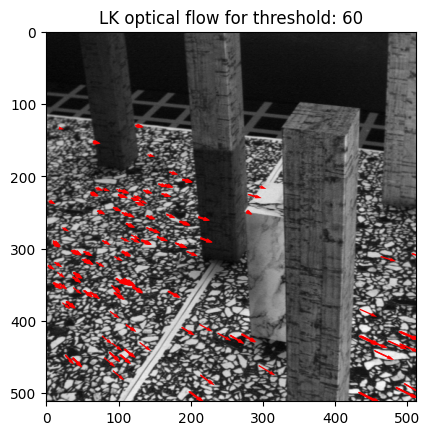

In [10]:
from vis_flow import plot_flow

# TODO: Edit this parameter to see different results.
threshmin = 60


# visualize flow
plt.figure()
plot_flow(images[..., valid_idx], flow, confidence, threshmin=threshmin)
plt.title(f'LK optical flow for threshold: {threshmin}')
plt.savefig(f"flow_{threshmin}.png")
plt.show()
plt.cla()
plt.clf()
plt.close()

## 4. Compute Epipole Points

Please fill the `epipole` function in file `epipole.py` .

Hint: if you successfully compute a right epiple, the lines of your optical flow will converge at that point approximately as shown in `example_epipole_70.png`

Computing epipole - this may take a while...
EPIPOLE:  [-407.41202958   32.82148306    1.        ]


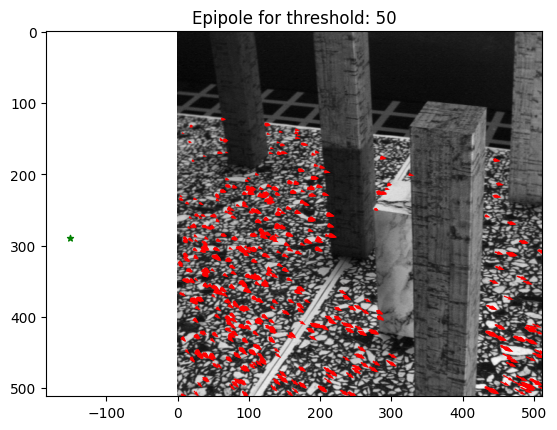

In [18]:
from epipole import epipole

# TODO: Edit this parameter to see different results.
threshmin = 50

# compute and visualize epipole
print('Computing epipole - this may take a while...')


ep = epipole(flow[..., 0], flow[..., 1], confidence, threshmin, num_iterations=1000)
ep = ep / ep[2]
print("EPIPOLE: ", ep)

# visualize flow and epipole

plt.figure()
plot_flow(images[..., valid_idx], flow, confidence, threshmin=threshmin)

# x = right, y = down
plt.scatter(ep[0] + flow.shape[0]//2, ep[1] + flow.shape[1]//2, c='g', s=20, marker='*')

plt.title(f'Epipole for threshold: {threshmin}')
plt.savefig(f"epipole_{threshmin}.png")
plt.show()
